In [1]:
import os
import sys

cur_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(cur_dir, '..', '..', '..'))
sys.path.append(root_dir)

example_dir = os.path.abspath(os.path.join(cur_dir, '..', '..'))
sys.path.append(example_dir)

data_dir = f'{root_dir}/data/regimes/vanderpol'

import math
import torch
import numpy as np
import matplotlib.pyplot as plt

import util_data
import util_vanderpol

In [2]:

t_dur       = 63
dt          = 1e-1
sim_nsample = int(t_dur / dt)
print(f'number of simulation steps is {sim_nsample}')

# --! specify dynamic-like initial conditions (mu is not zero)
ics_dyn = [
    np.array([ 1.0,  0.0]),
    np.array([ 0.5,  0.0]),

    np.array([ 0.0,  1.0]),
    np.array([ 0.0,  0.5]),

    np.array([-1.0,  0.0]),
    np.array([-0.5,  0.0]),

    np.array([ 0.0, -1.0]),
    np.array([ 0.0, -0.5])
]
mus_dyn = np.linspace(-0.2, 0.4, len(ics_dyn), endpoint=True)

# --! specify static-like initial conditions (mu is zero)
ics_sta = [
    np.array([ 1.0,  0.0]),
    np.array([-1.0,  0.0]),
    np.array([ 0.0,  1.0]),
    np.array([ 0.0, -1.0])
]
mus_sta = np.zeros(len(ics_sta))

ics = ics_dyn + ics_sta
mus = np.concatenate([mus_dyn, mus_sta])

number of simulation steps is 630


In [3]:

def sim_vanderpol(s0, mu, sim_nsample, dt):
    s = s0
    ss = []
    for i in range(sim_nsample):
        s = util_vanderpol.step_vanderpol(s, mu, dt=dt)

        ss.append(s)

    return np.stack(ss)

def plot_result(s, sim_nsample, period, dt, label=None):

    t = np.arange(sim_nsample) * dt
    p = period * dt
    x = s[:, 0]
    y = s[:, 1]

    if label is not None:
        label_boundaries = np.arange(len(label) + 1) * p

    plt.figure(figsize=(6, 3))

    xmin = min(x)
    xmax = max(x)

    plt.plot(t, x)

    if label is not None:
        for i in range(len(label_boundaries) - 1):
            c = 'red' if label[i]==1 else 'green'
            plt.axvspan(label_boundaries[i], label_boundaries[i + 1], alpha=0.3, color=c)

    else:
        plt.plot([0, 0], [xmin, xmax], color='gray', linestyle='dashed')
        plt.plot([p, p], [xmin, xmax], color='gray', linestyle='dashed')

    plt.xlabel('Time (s)')
    plt.ylabel('Position')

    plt.tight_layout()
    plt.show()

def measure_period(s):
    st = 0
    i0 = 0
    i1 = 0

    for i in range(len(s) - 1):
        if s[i, 0] > 0 and s[i+1, 0] < 0:
            if st==0:
                i0 = i
                st = 1
            elif st==1:
                i1 = i
                st = 2
                break

    return i1 - i0

def derive_label(traj, period_nsample):

    # --! split in PyTorch is more convenient than in NumPy, so use tensors
    s = torch.as_tensor(traj, dtype=torch.float32)
    ss = torch.split(s, period_nsample, dim=0)
    ss = [s.numpy() for s in ss]
    #print(ss[0].shape)
    #print(ss[-1].shape)

    rtol = 2e-2
    period_label = np.zeros(len(ss))

    # --! process first element in periods
    s0_max = max(ss[0][:, 0])
    s1_max = max(ss[1][:, 0])
    if not math.isclose(s0_max, s1_max, rel_tol=rtol):
        period_label[0] = 1

    # --! process period elements after first
    for i in range(len(ss) - 1):
        s0_max = max(ss[i][:, 0])
        s1_max = max(ss[i + 1][:, 0])
        if not math.isclose(s0_max, s1_max, rel_tol=rtol):
            period_label[i + 1] = 1

    return period_label


In [4]:
trajs = []
for s0, mu in zip(ics, mus):
    traj = sim_vanderpol(s0, mu, sim_nsample, dt)
    trajs.append(traj)

trajs = np.stack(trajs)
print(f'inf > shape of simulated trajectories is {trajs.shape}')


inf > shape of simulated trajectories is (12, 630, 2)


In [5]:
# --! measure oscillation period --!

ps = []
for traj in trajs:
    p = measure_period(traj)
    ps.append(p)

ps = np.stack(ps)
p = int(np.mean(ps))
p_dur = p * dt
print(f'inf > measured period is on average {p} samples of ~{p_dur:.2} seconds')

inf > measured period is on average 63 samples of ~6.3 seconds


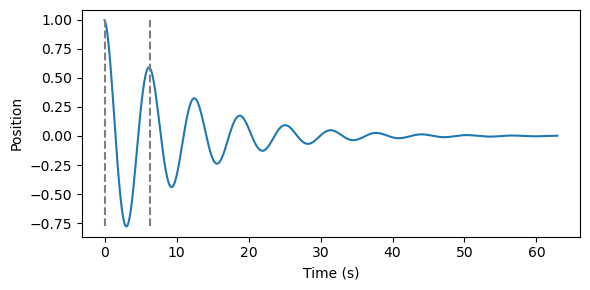

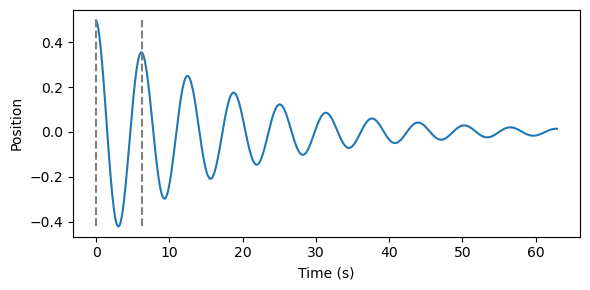

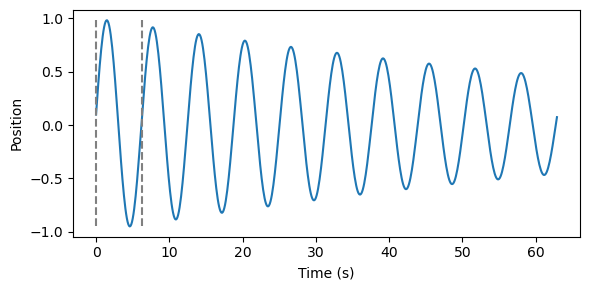

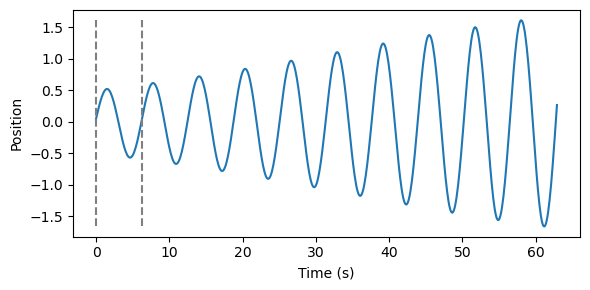

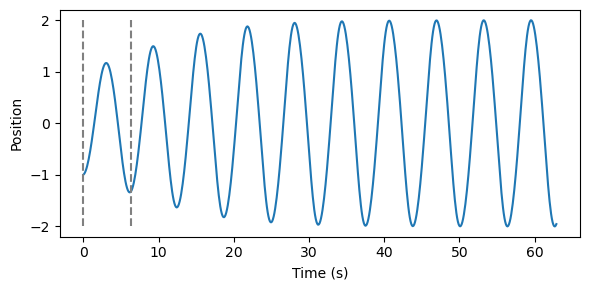

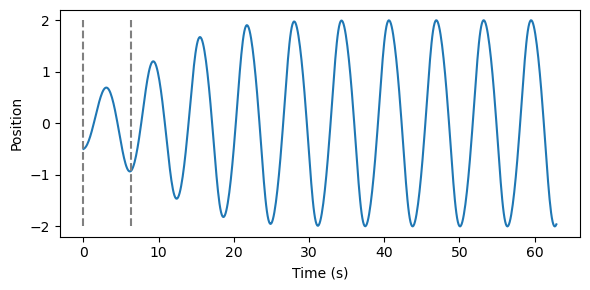

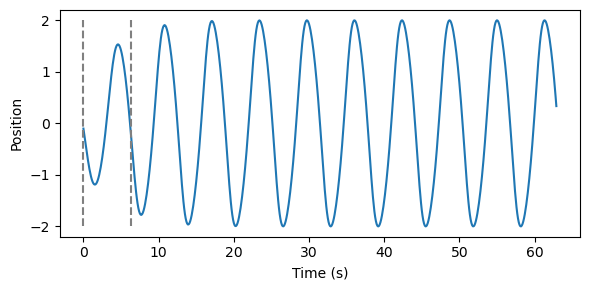

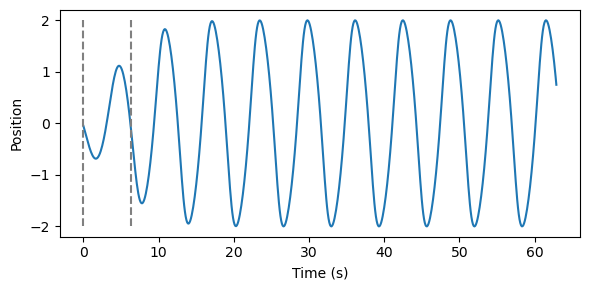

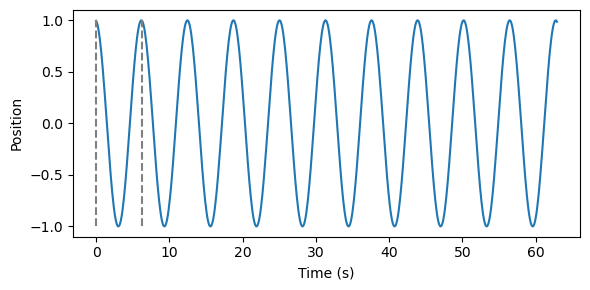

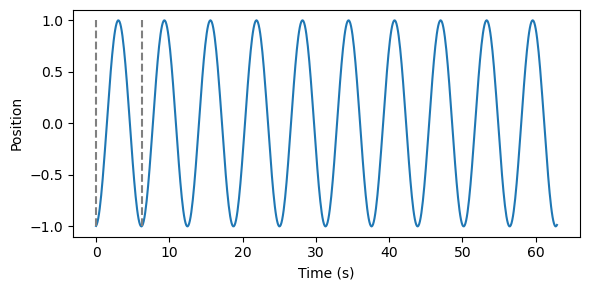

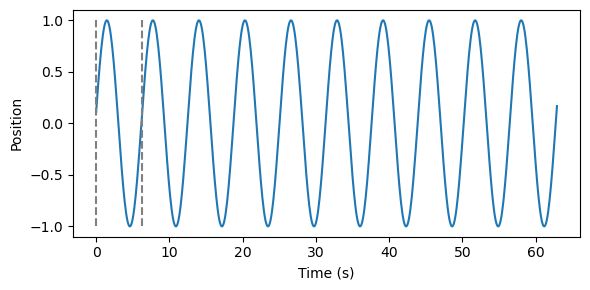

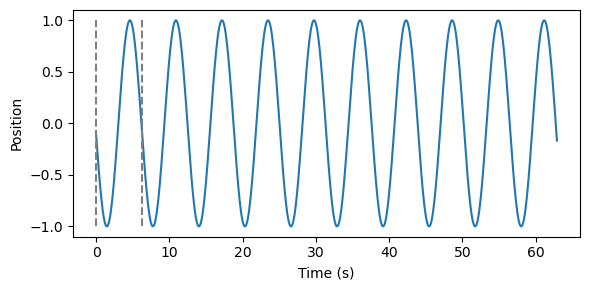

In [6]:
# --! display results --!

for traj in trajs:
    plot_result(traj, sim_nsample, p, dt)


In [7]:

labels = []

for traj in trajs:
    label = derive_label(traj, p)
    labels.append(label)

for j, label in enumerate(labels):
    print(f'{j}: {label}')

0: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
1: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
3: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
4: [1. 1. 1. 1. 1. 0. 0. 0. 0. 0.]
5: [1. 1. 1. 1. 1. 0. 0. 0. 0. 0.]
6: [1. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
7: [1. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
8: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
9: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
10: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
11: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


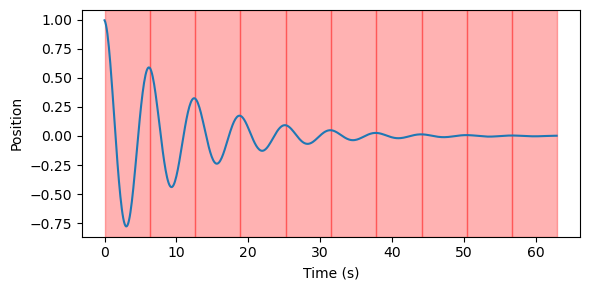

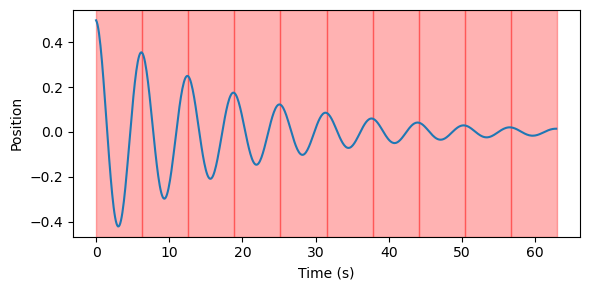

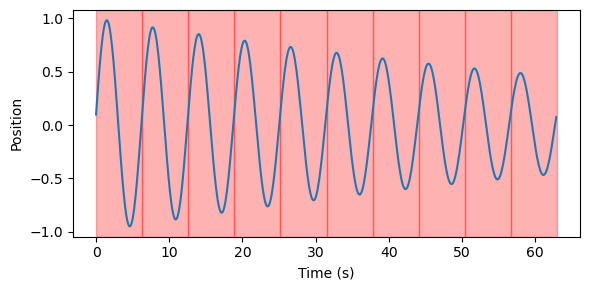

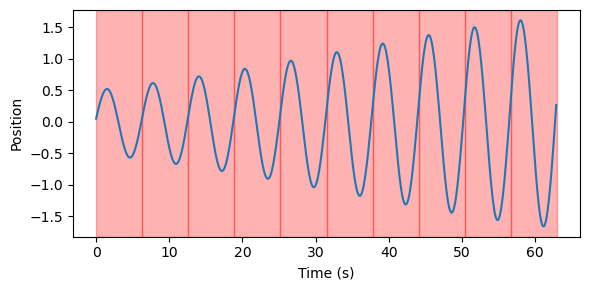

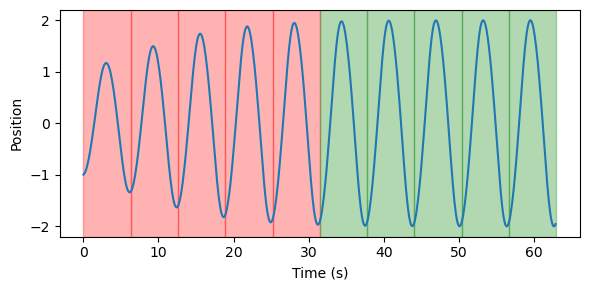

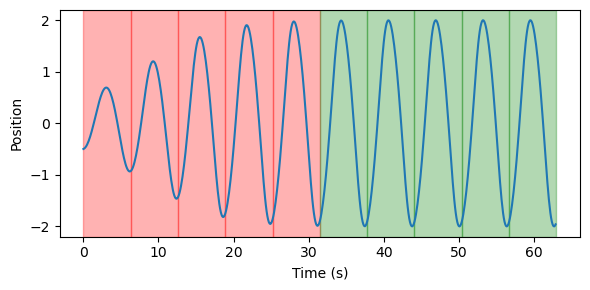

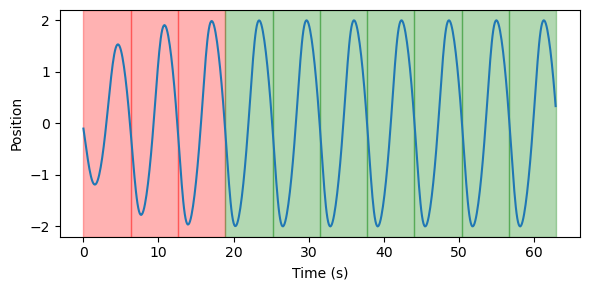

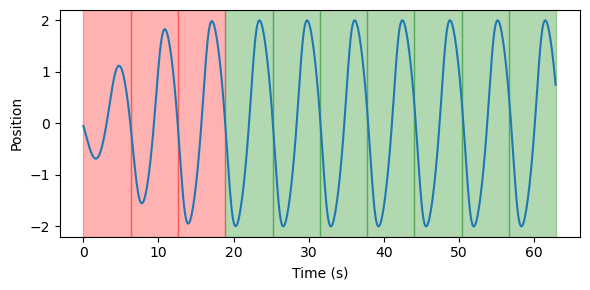

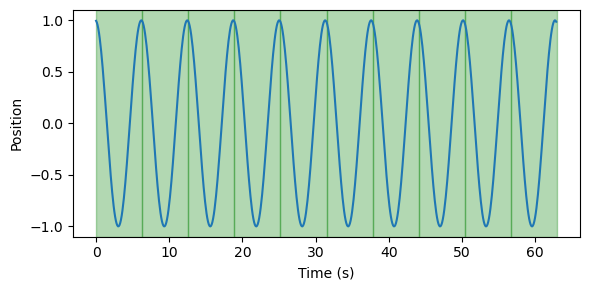

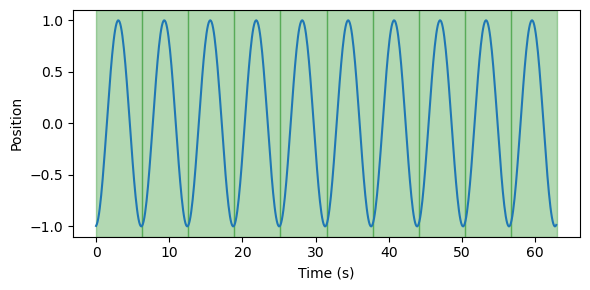

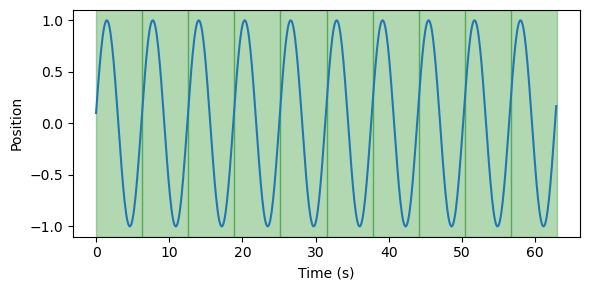

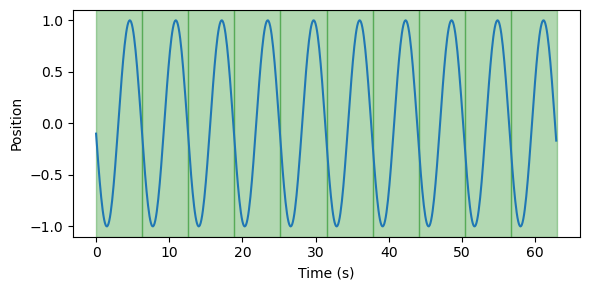

In [8]:
# --! display results --!

for traj, label in zip(trajs, labels):
    plot_result(traj, sim_nsample, p, dt, label)

In [9]:
# --! 

labels = np.stack(labels)
labels = np.expand_dims(np.repeat(labels, p, axis=1), -1)

print(f'inf > shape of labels is {labels.shape}')

inf > shape of labels is (12, 630, 1)


In [10]:
datasaved = True

if datasaved:
    util_data.write_datafile(f'{data_dir}/trajectories', trajs)
    print(f'inf > simulated trajectories saved')
    util_data.write_datafile(f'{data_dir}/labels', labels)
    print(f'inf > labels saved')

inf > simulated trajectories saved
inf > labels saved
